In [49]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np


In [50]:
data_path = '../data/'
df = pd.read_csv(data_path + 'Loan_data.csv')
dico = pd.read_excel(data_path + 'Dictionnaire_données.xlsx', sheet_name='Sheet1')
dico.drop(columns=['Unnamed: 0'], inplace=True)

In [51]:
count_na = df.isna().sum()
print(count_na)
df.dropna(inplace=True)

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

In [52]:
df_train, df_temp = train_test_split(df, test_size=0.4, random_state=42)

# Découpage de la partie restante en validation et test
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)


In [53]:
target='RiskScore'
X_train = df_train.drop(columns=[target])
y_train = df_train[target]
X_val = df_val.drop(columns=[target])
y_val = df_val[target]
X_test = df_test.drop(columns=[target])
y_test = df_test[target]

In [54]:
# col types
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved']
Categorical columns: ['ApplicationDate', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']


In [55]:
# catboost
from catboost import CatBoostRegressor, Pool

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
val_pool = Pool(X_val, y_val, cat_features=cat_cols)
test_pool = Pool(X_test, y_test, cat_features=cat_cols)

In [56]:
model_baseline = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

In [57]:
model_baseline.fit(train_pool, eval_set=val_pool)
y_pred = model_baseline.predict(test_pool)
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_test, y_pred)
print(f'RMSE on test set: {rmse}')
print(f'MAE on test set: {mean_absolute_error(y_test, y_pred)}')


0:	learn: 7.4139093	test: 7.5249256	best: 7.5249256 (0)	total: 8.07ms	remaining: 8.07s
100:	learn: 0.7490046	test: 0.7945510	best: 0.7945510 (100)	total: 554ms	remaining: 4.93s
200:	learn: 0.4075004	test: 0.4547290	best: 0.4547290 (200)	total: 1.01s	remaining: 4.04s
300:	learn: 0.2930884	test: 0.3467592	best: 0.3467592 (300)	total: 1.64s	remaining: 3.81s
400:	learn: 0.2350220	test: 0.2947158	best: 0.2947158 (400)	total: 2.23s	remaining: 3.33s
500:	learn: 0.2020011	test: 0.2672459	best: 0.2672459 (500)	total: 2.85s	remaining: 2.84s
600:	learn: 0.1813612	test: 0.2508539	best: 0.2508539 (600)	total: 3.41s	remaining: 2.26s
700:	learn: 0.1665733	test: 0.2407397	best: 0.2407150 (699)	total: 3.91s	remaining: 1.67s
800:	learn: 0.1551958	test: 0.2346539	best: 0.2346539 (800)	total: 4.58s	remaining: 1.14s
900:	learn: 0.1464385	test: 0.2302439	best: 0.2302439 (900)	total: 5.04s	remaining: 554ms
999:	learn: 0.1394272	test: 0.2270944	best: 0.2270944 (999)	total: 5.48s	remaining: 0us

bestTest = 0.2

In [58]:
print(y_pred[:10])
print(y_test.values[:10])

[47.02751358 38.30656556 38.36434017 51.03158697 49.05037536 46.09217667
 57.22717851 50.96345687 42.28081857 55.98311679]
[47.  38.4 38.4 51.  49.  46.  57.  51.  42.4 56. ]


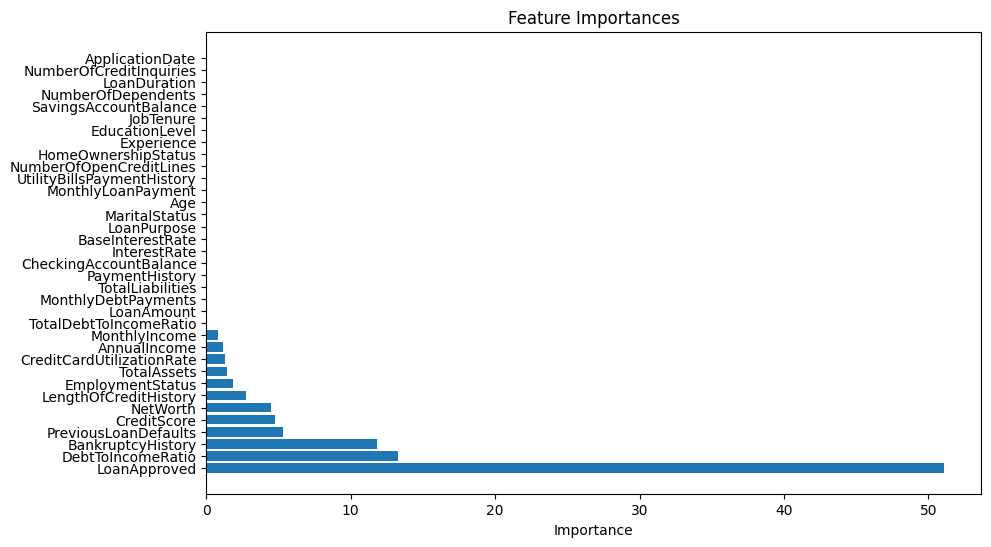

In [59]:
# feature importance
import matplotlib.pyplot as plt
feature_importances = model_baseline.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature Id'], feature_importances['Importances'])
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()
